In [38]:
import pandas as pd

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

train.head()


,name,year,month,day,hour,lat,long,status,category,wind,pressure,tropicalstorm_force_diameter,hurricane_force_diameter,hurricane_class
0,Humberto,1995,8,26,0,19.4,-46.6,hurricane,2.0,90,970,242,60,0
1,Opal,1995,10,5,0,31.0,-86.8,hurricane,1.0,80,950,367,115,0
2,Sam,2021,10,3,60,36.7,-56.6,hurricane,2.0,90,960,400,60,0
3,Irene,1981,9,28,12,27.0,-56.7,hurricane,3.0,105,959,217,60,1
4,Emily,1993,8,30,18,32.0,-72.2,hurricane,1.0,75,974,237,66,0


Separate predictors and target


In [39]:
X_train = train.drop(columns=['hurricane_class'])
y_train = train['hurricane_class']

X_test = test.drop(columns=['hurricane_class'])
y_test = test['hurricane_class']

In [40]:
#Remove the 'category' column to avoid data leakage
X_train = X_train.drop(columns=['category'])
X_test = X_test.drop(columns=['category'])

Random Forest

In [41]:
# Check which columns are text/object columns
print(X_train.select_dtypes(include='object').columns)

Index(['name', 'status'], dtype='object')


In [42]:
print(X_train.select_dtypes(include='object').columns)

Index(['name', 'status'], dtype='object')


In [43]:
# Reload data
import pandas as pd

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

# Separate target
X_train = train.drop(columns=["hurricane_class"])
y_train = train["hurricane_class"]

X_test = test.drop(columns=["hurricane_class"])
y_test = test["hurricane_class"]

# Remove text columns and leakage column
drop_cols = ["name", "status", "category"]

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

# Check that only numeric columns remain
print(X_train.dtypes)

year                              int64
month                             int64
day                               int64
hour                              int64
lat                             float64
long                            float64
wind                              int64
pressure                          int64
tropicalstorm_force_diameter      int64
hurricane_force_diameter          int64
dtype: object


In [44]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [45]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

Radom Forest Evaluation

In [46]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))
print("Accuracy:", accuracy_score(y_test, rf_pred))

[[734   0]
 [  0 286]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       734
           1       1.00      1.00      1.00       286

    accuracy                           1.00      1020
   macro avg       1.00      1.00      1.00      1020
weighted avg       1.00      1.00      1.00      1020

Accuracy: 1.0


Feature Importance

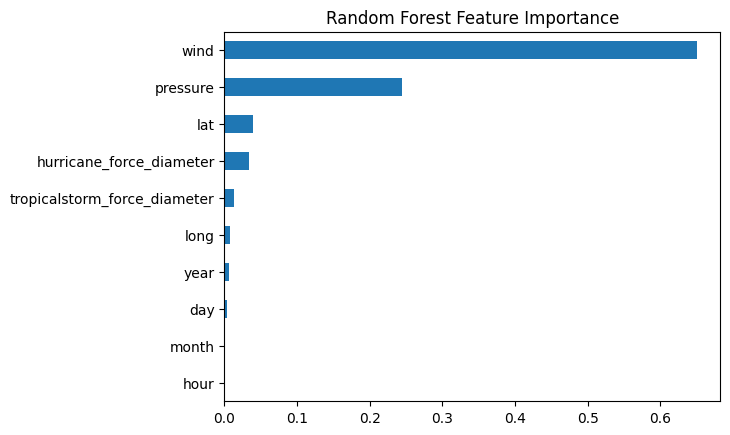

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

importance_rf = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

importance_rf.sort_values().plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.show()

In [48]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4080 entries, 0 to 4079
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   year                          4080 non-null   int64  
 1   month                         4080 non-null   int64  
 2   day                           4080 non-null   int64  
 3   hour                          4080 non-null   int64  
 4   lat                           4080 non-null   float64
 5   long                          4080 non-null   float64
 6   wind                          4080 non-null   int64  
 7   pressure                      4080 non-null   int64  
 8   tropicalstorm_force_diameter  4080 non-null   int64  
 9   hurricane_force_diameter      4080 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 318.9 KB
None


Gradient Boosting

In [49]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

Gradient Boosting Evaluation

In [50]:
print(confusion_matrix(y_test, gb_pred))
print(classification_report(y_test, gb_pred))
print("Accuracy:", accuracy_score(y_test, gb_pred))

[[734   0]
 [  0 286]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       734
           1       1.00      1.00      1.00       286

    accuracy                           1.00      1020
   macro avg       1.00      1.00      1.00      1020
weighted avg       1.00      1.00      1.00      1020

Accuracy: 1.0


In [51]:
print(X_train.columns)

Index(['year', 'month', 'day', 'hour', 'lat', 'long', 'wind', 'pressure',
       'tropicalstorm_force_diameter', 'hurricane_force_diameter'],
      dtype='object')


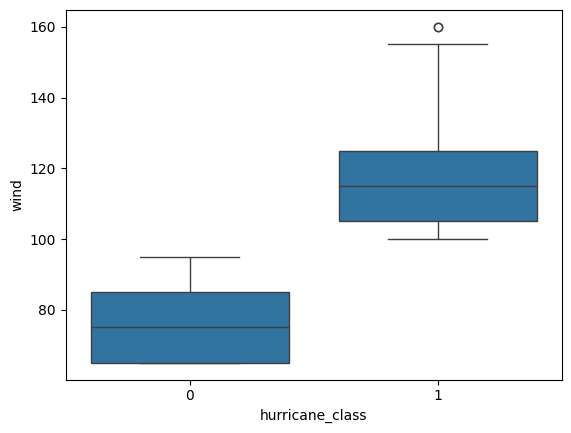

In [52]:
train.groupby('hurricane_class')['wind'].describe()
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='hurricane_class', y='wind', data=train)
plt.show()

In [53]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [54]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print(confusion_matrix(y_test, gb_pred))
print(classification_report(y_test, gb_pred))
print("Accuracy:", accuracy_score(y_test, gb_pred))

[[734   0]
 [  0 286]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       734
           1       1.00      1.00      1.00       286

    accuracy                           1.00      1020
   macro avg       1.00      1.00      1.00      1020
weighted avg       1.00      1.00      1.00      1020

Accuracy: 1.0


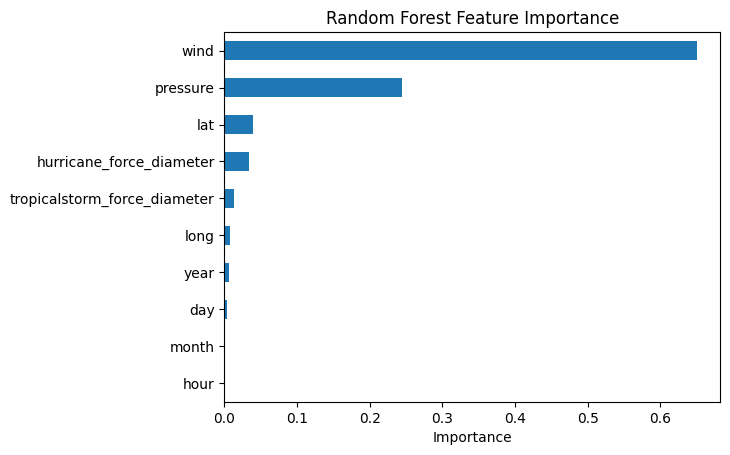

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

importance_rf = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

importance_rf.sort_values().plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

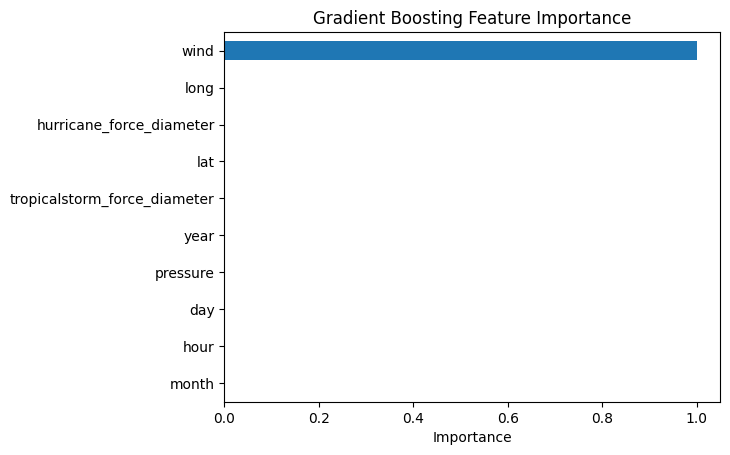

In [56]:
importance_gb = pd.Series(
    gb_model.feature_importances_,
    index=X_train.columns
)

importance_gb.sort_values().plot(kind='barh')
plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.show()